In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn shap streamlit joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 79.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import shap
import joblib

import warnings
warnings.filterwarnings("ignore")

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    "checking_status",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_status",
    "employment",
    "installment_rate",
    "personal_status",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "num_dependents",
    "telephone",
    "foreign_worker",
    "credit_risk"
]

df = pd.read_csv(
    url,
    sep=" ",
    header=None,
    names=columns
)

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["credit_risk"].value_counts())

Shape: (1000, 21)

Columns:
['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_rate', 'personal_status', 'other_debtors', 'residence_since', 'property', 'age', 'other_installment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'telephone', 'foreign_worker', 'credit_risk']

Missing values:
checking_status            0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings_status             0
employment                 0
installment_rate           0
personal_status            0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
num_dependents             0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64


In [5]:
df["credit_risk"] = df["credit_risk"].map({
    1: 0,
    2: 1
})

df["credit_risk"].value_counts()

,count
credit_risk,
0,700
1,300


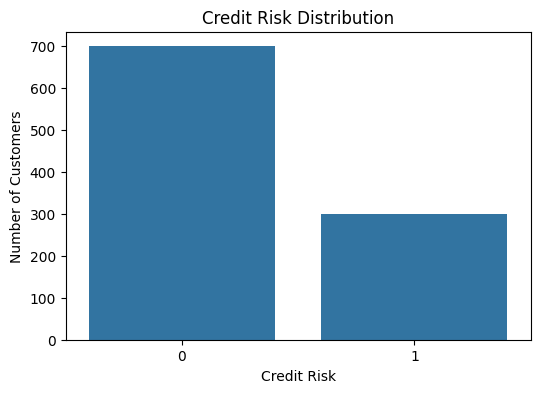

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="credit_risk"
)

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")

plt.show()

In [7]:
numerical_features = [
    "duration",
    "credit_amount",
    "installment_rate",
    "residence_since",
    "age",
    "existing_credits",
    "num_dependents"
]

df[numerical_features].describe()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


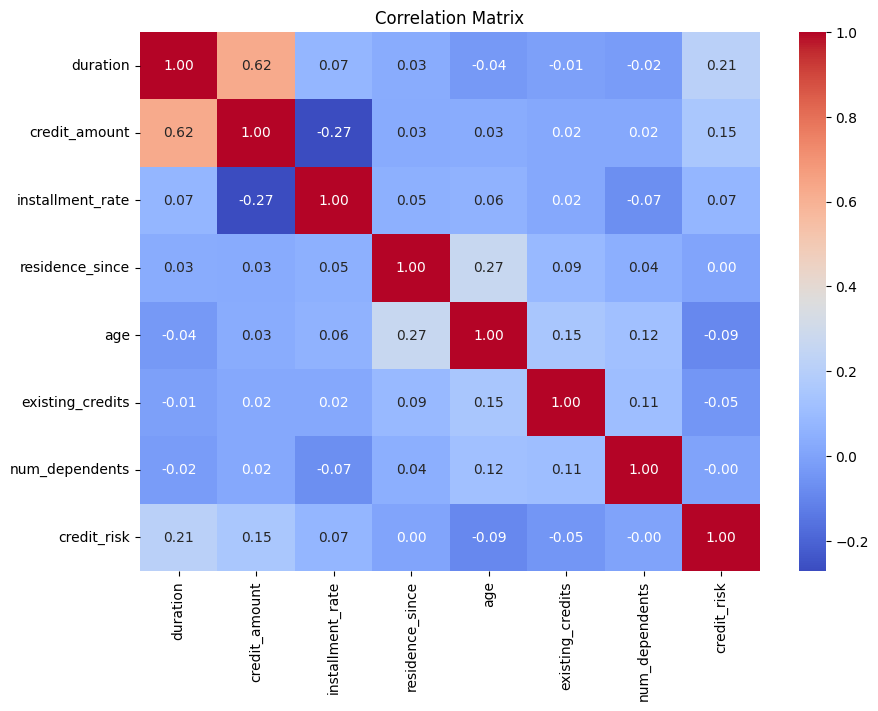

In [8]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numerical_features + ["credit_risk"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# **Feature Engineering**

Credit amount relative to age:

In [9]:
df["credit_to_age_ratio"] = (
    df["credit_amount"] / df["age"]
)

Credit duration relative to age

In [10]:
df["duration_to_age_ratio"] = (
    df["duration"] / df["age"]
)

Credit amount per month

In [11]:
df["monthly_credit_burden"] = (
    df["credit_amount"] / df["duration"]
)

In [12]:
df[
    [
        "credit_amount",
        "age",
        "duration",
        "credit_to_age_ratio",
        "duration_to_age_ratio",
        "monthly_credit_burden"
    ]
].head()

,credit_amount,age,duration,credit_to_age_ratio,duration_to_age_ratio,monthly_credit_burden
0,1169,67,6,17.447761,0.089552,194.833333
1,5951,22,48,270.500000,2.181818,123.979167
2,2096,49,12,42.775510,0.244898,174.666667
3,7882,45,42,175.155556,0.933333,187.666667
4,4870,53,24,91.886792,0.452830,202.916667


## Separate X and **y**

In [13]:
X = df.drop("credit_risk", axis=1)
y = df["credit_risk"]

In [14]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

Numerical features:
['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents', 'credit_to_age_ratio', 'duration_to_age_ratio', 'monthly_credit_burden']


#**Preprocessing pipeline**

In [15]:
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# **Train-test split**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


# **Logistic Regression**

In [17]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['duration', 'credit_amount',
                                                   'installment_rate',
                                                   'residence_since', 'age',
                                                   'existing_credits',
                                                   'num_dependents',
                                                   'credit_to_age_ratio',
                                                   'duration_to_age_ratio',
                                                   'monthly_credit_burden']),
                                                 ('cat',
                                                  Pi...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['checking_status',
                                                   'credit_history', 'purpose',
                                                   'savings_status',
                                                   'employment',
                                                   'personal_status',
                                                   'other_debtors', 'property',
                                                   'other_installment_plans',
                                                   'housing', 'job',
                                                   'telephone',
                                                   'foreign_worker'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

**Predictions:**

In [18]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

**Evaluate:**

In [19]:
print("Logistic Regression")
print("--------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_lr)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_lr)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_lr)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_lr)
)

Logistic Regression
--------------------
Accuracy: 0.74
Precision: 0.5465116279069767
Recall: 0.7833333333333333
F1 Score: 0.6438356164383562
ROC-AUC: 0.8091666666666667


# **Model comparison**

In [22]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("--------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_rf)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_rf)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_rf)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_rf)
)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

Random Forest
--------------------
Accuracy: 0.78
Precision: 0.75
Recall: 0.4
F1 Score: 0.5217391304347826
ROC-AUC: 0.7972619047619047


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.74,0.546512,0.783333,0.643836,0.809167
1,Random Forest,0.78,0.750000,0.400000,0.521739,0.797262


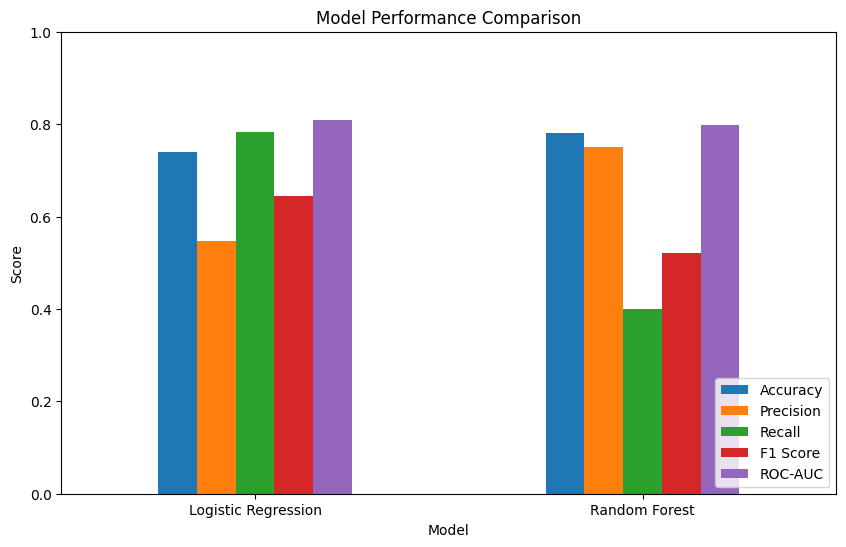

In [24]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

# **Confusion Matrix**

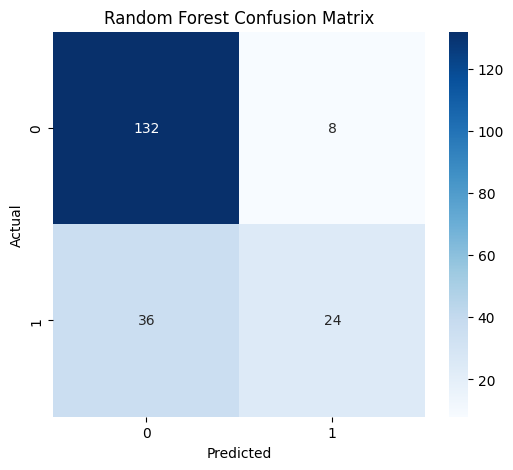

              precision    recall  f1-score   support

 Good Credit       0.79      0.94      0.86       140
  Bad Credit       0.75      0.40      0.52        60

    accuracy                           0.78       200
   macro avg       0.77      0.67      0.69       200
weighted avg       0.78      0.78      0.76       200



In [25]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Good Credit",
            "Bad Credit"
        ]
    )
)

# **ROC Curve**

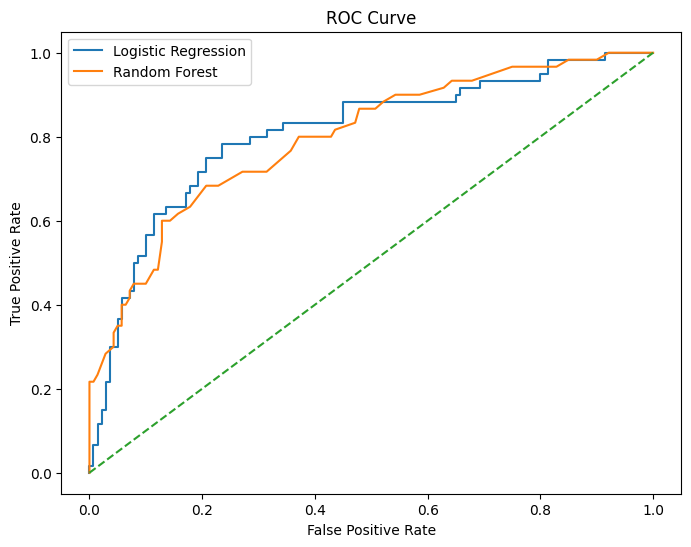

In [26]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label="Logistic Regression"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# **Feature Importance**

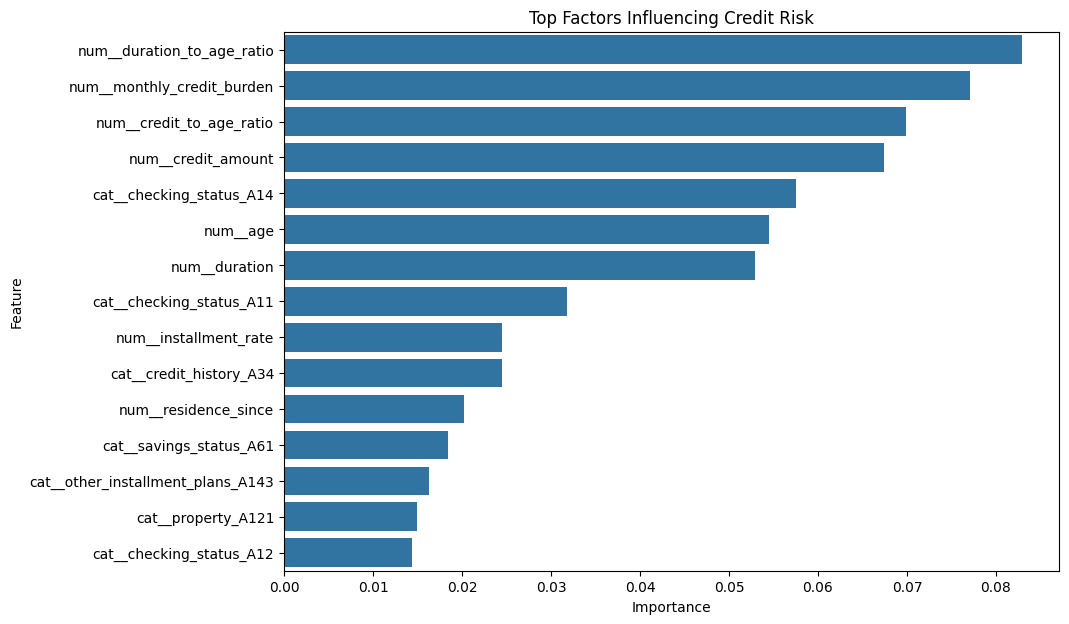

In [28]:
preprocessor_fitted = (
    random_forest_model
    .named_steps["preprocessor"]
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

feature_names[:20]

rf_classifier = (
    random_forest_model
    .named_steps["classifier"]
)

importances = rf_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(15)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Factors Influencing Credit Risk")

plt.show()

# **SHAP Explainability**

<class 'numpy.ndarray'>


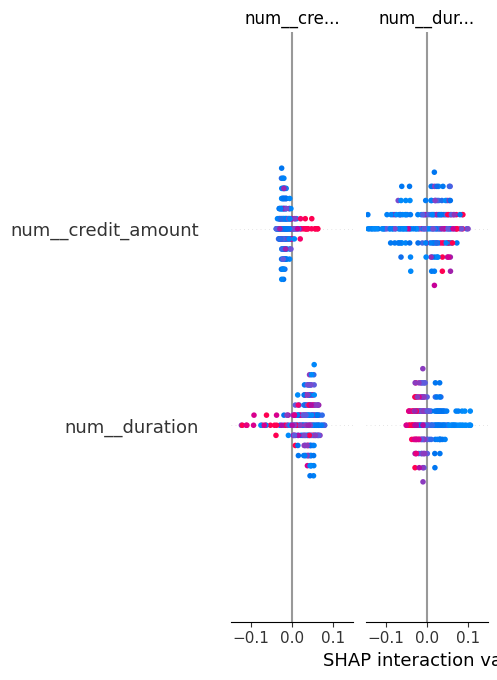

In [30]:
X_test_processed = (
    preprocessor_fitted
    .transform(X_test)
)

explainer = shap.TreeExplainer(
    rf_classifier
)

shap_values = explainer.shap_values(
    X_test_processed
)

print(type(shap_values))

if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_test_processed,
        feature_names=feature_names
    )
else:
    shap.summary_plot(
        shap_values,
        X_test_processed,
        feature_names=feature_names
    )

# **Individual customer prediction**

In [32]:
def predict_credit_risk(customer_data):

    prediction = random_forest_model.predict(
        customer_data
    )[0]

    probability = random_forest_model.predict_proba(
        customer_data
    )[0][1]

    if prediction == 1:
        risk = "HIGH RISK"
    else:
        risk = "LOWER RISK"

    return risk, probability

sample_customer = X_test.iloc[[0]]

risk, probability = predict_credit_risk(
    sample_customer
)

print("Prediction:", risk)
print(
    "Bad-credit probability:",
    round(probability * 100, 2),
    "%"
)

Prediction: LOWER RISK
Bad-credit probability: 30.0 %


# **Model-derived risk score**

In [33]:
def calculate_risk_score(probability):

    score = 100 - (probability * 100)

    return round(score, 2)


risk_score = calculate_risk_score(probability)

print("Credit Risk Score:", risk_score, "/ 100")


def risk_category(score):

    if score >= 70:
        return "Low Risk"
    elif score >= 40:
        return "Moderate Risk"
    else:
        return "High Risk"
print(
    "Risk Category:",
    risk_category(risk_score)
)

Credit Risk Score: 70.0 / 100
Risk Category: Low Risk


# **Save the model**

In [34]:
joblib.dump(
    random_forest_model,
    "credit_risk_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [35]:
loaded_model = joblib.load(
    "credit_risk_model.pkl"
)

In [36]:
from google.colab import files

files.download("credit_risk_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
import sklearn
print(sklearn.__version__)

1.6.1
